In [3]:
import pandas as pd

# Load your cleaned and transformed data
df = pd.read_csv("cleaned_iot_data1.csv")

# Check a few rows
print(df.head())


             timestamp  device_id    data_type  data_value  numeric_value
0  2025-06-15 19:47:13  Station_C        PM2.5         146          146.0
1  2025-06-15 19:47:13  Station_C          CO2         390          390.0
2  2025-06-15 19:47:13  Station_C  temperature          25           25.0
3  2025-06-15 19:47:13  Station_C     humidity          44           44.0
4  2025-06-15 19:47:13  Station_C          AQI         105          105.0


In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df

,timestamp,device_id,data_type,data_value,numeric_value
0,2025-06-15 19:47:13,Station_C,PM2.5,146,146.0
1,2025-06-15 19:47:13,Station_C,CO2,390,390.0
2,2025-06-15 19:47:13,Station_C,temperature,25,25.0
3,2025-06-15 19:47:13,Station_C,humidity,44,44.0
4,2025-06-15 19:47:13,Station_C,AQI,105,105.0
...,...,...,...,...,...
495,2025-06-15 19:48:55,Station_B,PM2.5,124,124.0
496,2025-06-15 19:48:55,Station_B,CO2,322,322.0
497,2025-06-15 19:48:55,Station_B,temperature,15,15.0
498,2025-06-15 19:48:55,Station_B,humidity,60,60.0


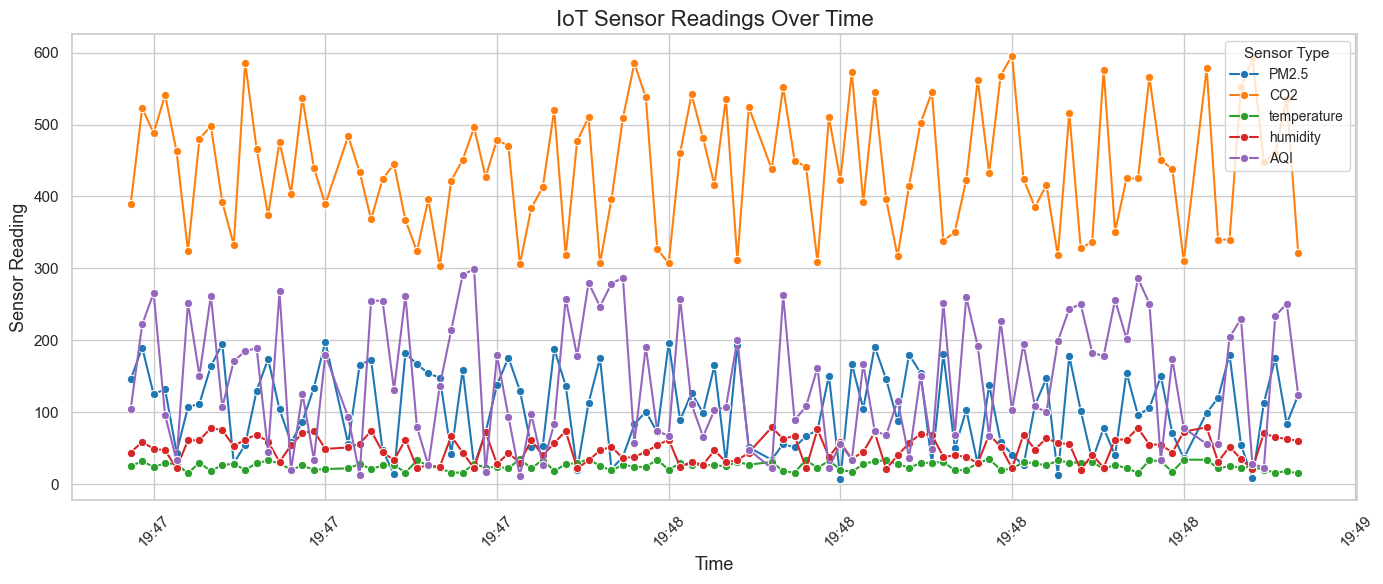

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Set visualization style
sns.set(style="whitegrid")

# Initialize figure size
plt.figure(figsize=(14, 6))

# Create line plot
sns.lineplot(
    data=df,
    x="timestamp",
    y="numeric_value",
    hue="data_type",
    marker="o",
    linewidth=1.5,
    palette="tab10"
)

# Format the x-axis for better readability
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # show time only
plt.xticks(rotation=45)

# Add labels and title
plt.title("IoT Sensor Readings Over Time", fontsize=16)
plt.xlabel("Time", fontsize=13)
plt.ylabel("Sensor Reading", fontsize=13)

# Add legend
plt.legend(title="Sensor Type", fontsize=10, title_fontsize=11, loc="upper right")

# Improve layout spacing
plt.tight_layout()

# Show the plot
plt.show()


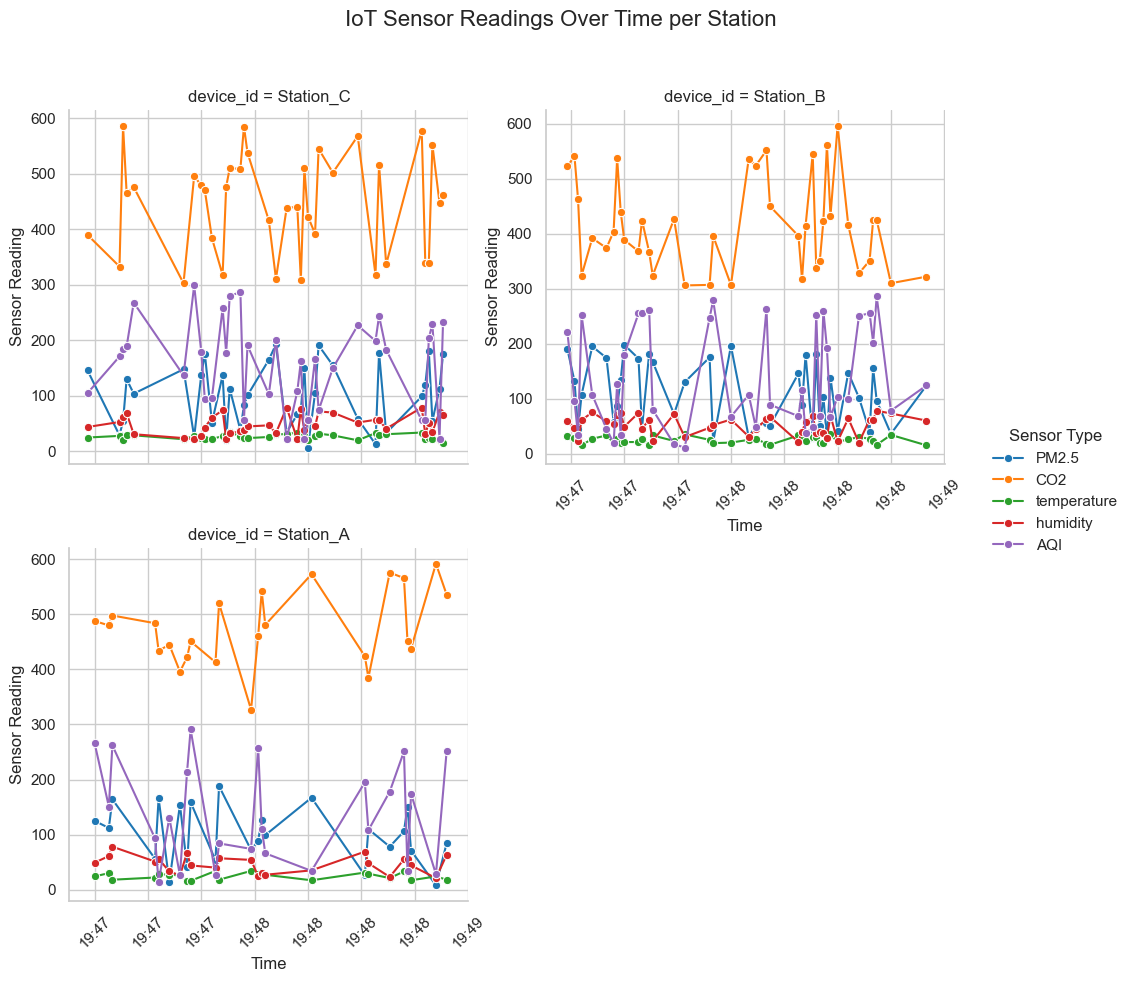

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert timestamp column to datetime (if not done yet)
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Set style
sns.set(style="whitegrid")

# Create FacetGrid: one subplot per station
g = sns.FacetGrid(df, col="device_id", col_wrap=2, height=5, sharey=False)

# Add line plots to each subplot
g.map_dataframe(
    sns.lineplot,
    x="timestamp",
    y="numeric_value",
    hue="data_type",
    marker="o",
    linewidth=1.5,
    palette="tab10"
)

# Customize each subplot
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel("Time")
    ax.set_ylabel("Sensor Reading")

# Add a main title
g.fig.suptitle("IoT Sensor Readings Over Time per Station", fontsize=16)
g.add_legend(title="Sensor Type")
g.tight_layout()
g.fig.subplots_adjust(top=0.88)  # Adjust to make space for suptitle

# Show plot
plt.show()


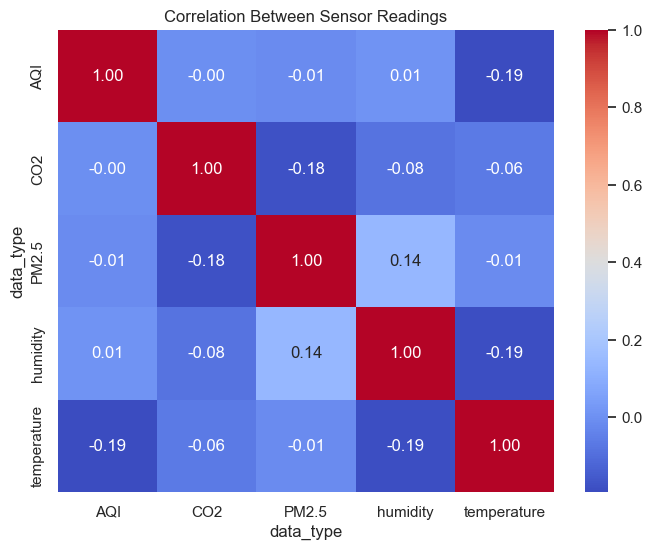

In [7]:
# Heatmap of Sensor Correlations

pivot_df = df.pivot_table(index="timestamp", columns="data_type", values="numeric_value", aggfunc="mean")

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Sensor Readings")
plt.show()


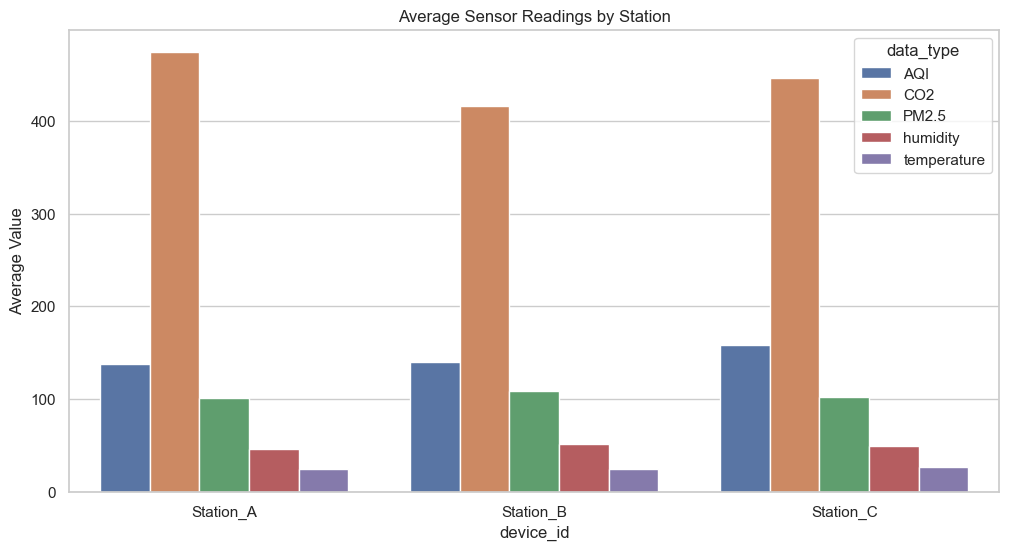

In [11]:
#Station-wise Bar Plot of Average Readings

avg_df = df.groupby(["device_id", "data_type"])["numeric_value"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_df, x="device_id", y="numeric_value", hue="data_type")
plt.title("Average Sensor Readings by Station")
plt.ylabel("Average Value")
plt.show()